In [13]:
import pandas as pd
import numpy as np

In [14]:
df = pd.read_csv("stu.csv")

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50800 entries, 0 to 50799
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            50800 non-null  int64  
 1   age                   50800 non-null  float64
 2   gender                50800 non-null  object 
 3   academic_year         50800 non-null  int64  
 4   study_hours_per_day   50800 non-null  float64
 5   exam_pressure         50800 non-null  float64
 6   academic_performance  50800 non-null  float64
 7   stress_level          50800 non-null  float64
 8   anxiety_score         50800 non-null  float64
 9   depression_score      50800 non-null  float64
 10  sleep_hours           50800 non-null  float64
 11  physical_activity     50800 non-null  float64
 12  social_support        50800 non-null  float64
 13  screen_time           50800 non-null  float64
 14  internet_usage        50800 non-null  float64
 15  financial_stress   

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
# --- ทำ Missing Values ---
# สุ่มให้ค่าใน 'study_hours_per_day' และ 'stress_level' หายไปประมาณ 10%
df.loc[df.sample(frac=0.07).index, 'study_hours_per_day'] = np.nan
df.loc[df.sample(frac=0.1).index, 'stress_level'] = np.nan

# --- ทำ Duplicated Data ---
# สุ่มแถวมา 50 แถวแล้วเอามาแปะซ้ำเข้าไปใน DataFrame
extra_duplicates = df.sample(n=50, random_state=42)
df = pd.concat([df, extra_duplicates], ignore_index=True)

# --- ทำ Outliers ---
# ใส่ค่าที่ "เป็นไปไม่ได้" หรือ "สูงผิดปกติ" ลงไป
# เช่น คนที่เรียน 999 ชั่วโมงต่อวัน หรือ อายุ 500 ปี
df.loc[0, 'study_hours_per_day'] = 999 
df.loc[1, 'age'] = 500
df.loc[2, 'exam_pressure'] = -50  # ค่าติดลบที่ปกติไม่มี

# 2. บันทึกเป็นไฟล์ใหม่
# df.to_csv('student_messy.csv', index=False)
# print("สร้างไฟล์ 'student_messy.csv' เรียบร้อยแล้ว!")

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50850 entries, 0 to 50849
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            50850 non-null  int64  
 1   age                   50850 non-null  float64
 2   gender                50850 non-null  object 
 3   academic_year         50850 non-null  int64  
 4   study_hours_per_day   47290 non-null  float64
 5   exam_pressure         50850 non-null  float64
 6   academic_performance  50850 non-null  float64
 7   stress_level          45764 non-null  float64
 8   anxiety_score         50850 non-null  float64
 9   depression_score      50850 non-null  float64
 10  sleep_hours           50850 non-null  float64
 11  physical_activity     50850 non-null  float64
 12  social_support        50850 non-null  float64
 13  screen_time           50850 non-null  float64
 14  internet_usage        50850 non-null  float64
 15  financial_stress   

In [19]:
df.duplicated().sum()

np.int64(50)

In [20]:
df.head()

,Unnamed: 0,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,...,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,0,27.0,Male,1,999.000000,7.212967,75.874596,6.320992,3.681433,3.020910,...,3.596473,3.192063,4.069784,4.022018,5.532280,4.419533,4.073012,5.460900,Medium,2.252533
1,1,500.0,Other,2,5.769301,5.745349,66.774579,5.977205,4.721597,0.000000,...,3.719423,5.911254,6.964381,7.011574,8.974861,7.782157,1.065080,6.192639,Low,1.522305
2,2,20.0,Male,2,NaN,-50.000000,69.333360,4.530619,4.304705,0.101967,...,1.715309,3.021740,3.493376,3.711292,5.671487,6.753917,1.053849,6.865751,Low,1.393980
3,3,20.0,Female,3,5.328554,4.788070,65.492226,0.603856,0.943924,0.000000,...,1.578477,7.814543,6.412061,7.010148,4.975130,5.048209,0.000000,9.475280,Low,0.000000
4,4,24.0,Female,1,6.207188,6.862395,69.820009,NaN,1.530294,0.648765,...,5.472070,4.488694,4.864239,4.411566,4.823738,5.564477,0.154420,7.894181,Low,0.000000


In [21]:
df.loc[df.sample(frac=0.001).index, 'age'] = np.nan
df.loc[df.sample(frac=0.01).index, 'sleep_hours'] = np.nan

In [22]:
df.loc[df.sample(frac=0.001).index, 'age'] = np.nan
df.loc[df.sample(frac=0.01).index, 'sleep_hours'] = np.nan

In [24]:
df.loc[df.sample(frac=0.01).index, 'financial_stress'] = np.nan
df.loc[df.sample(frac=0.001).index, 'risk_level'] = np.nan

In [25]:
df.isnull().sum()

Unnamed: 0                 0
age                      102
gender                     0
academic_year              0
study_hours_per_day     3560
exam_pressure              0
academic_performance       0
stress_level            5086
anxiety_score              0
depression_score           0
sleep_hours             1013
physical_activity          0
social_support             0
screen_time                0
internet_usage             0
financial_stress         508
family_expectation         0
burnout_score              0
mental_health_index        0
risk_level                51
dropout_risk               0
dtype: int64

In [26]:
import missingno as msno

<Axes: >

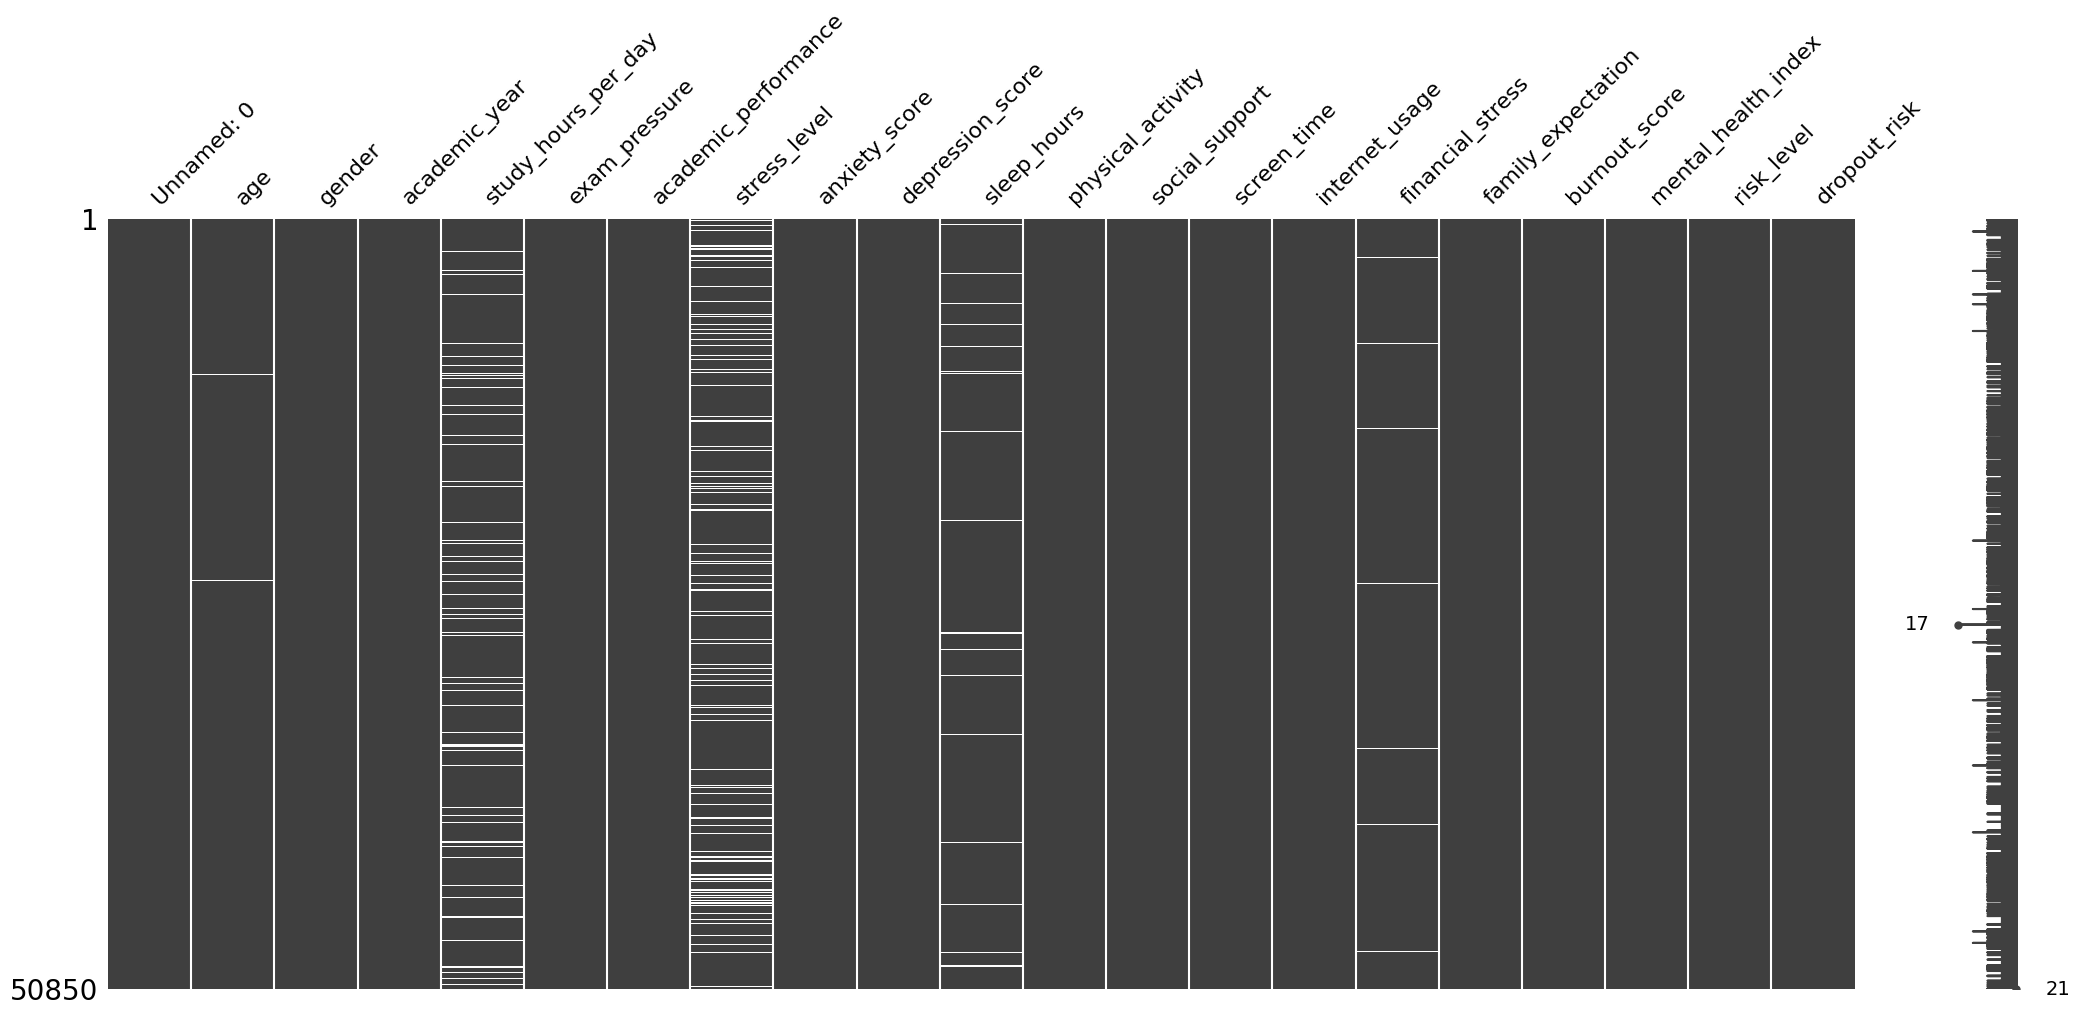

In [27]:
msno.matrix(df)

In [32]:
def outliner(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3-q1

    lower = q1 - 1.5 * iqr
    upper = q1 + 1.5 * iqr

    return lower, upper

In [28]:
num = df.select_dtypes(include=["number"]).columns
num

Index(['Unnamed: 0', 'age', 'academic_year', 'study_hours_per_day',
       'exam_pressure', 'academic_performance', 'stress_level',
       'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity',
       'social_support', 'screen_time', 'internet_usage', 'financial_stress',
       'family_expectation', 'burnout_score', 'mental_health_index',
       'dropout_risk'],
      dtype='object')

In [33]:
for col in num:
    lower, upper = outliner(df, col)
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col} : {count}")

Unnamed: 0 : 6
age : 58
academic_year : 0
study_hours_per_day : 4245
exam_pressure : 4584
academic_performance : 4658
stress_level : 4037
anxiety_score : 4477
depression_score : 4638
sleep_hours : 4357
physical_activity : 4603
social_support : 4515
screen_time : 4632
internet_usage : 4590
financial_stress : 4469
family_expectation : 4689
burnout_score : 4711
mental_health_index : 4147
dropout_risk : 5203


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

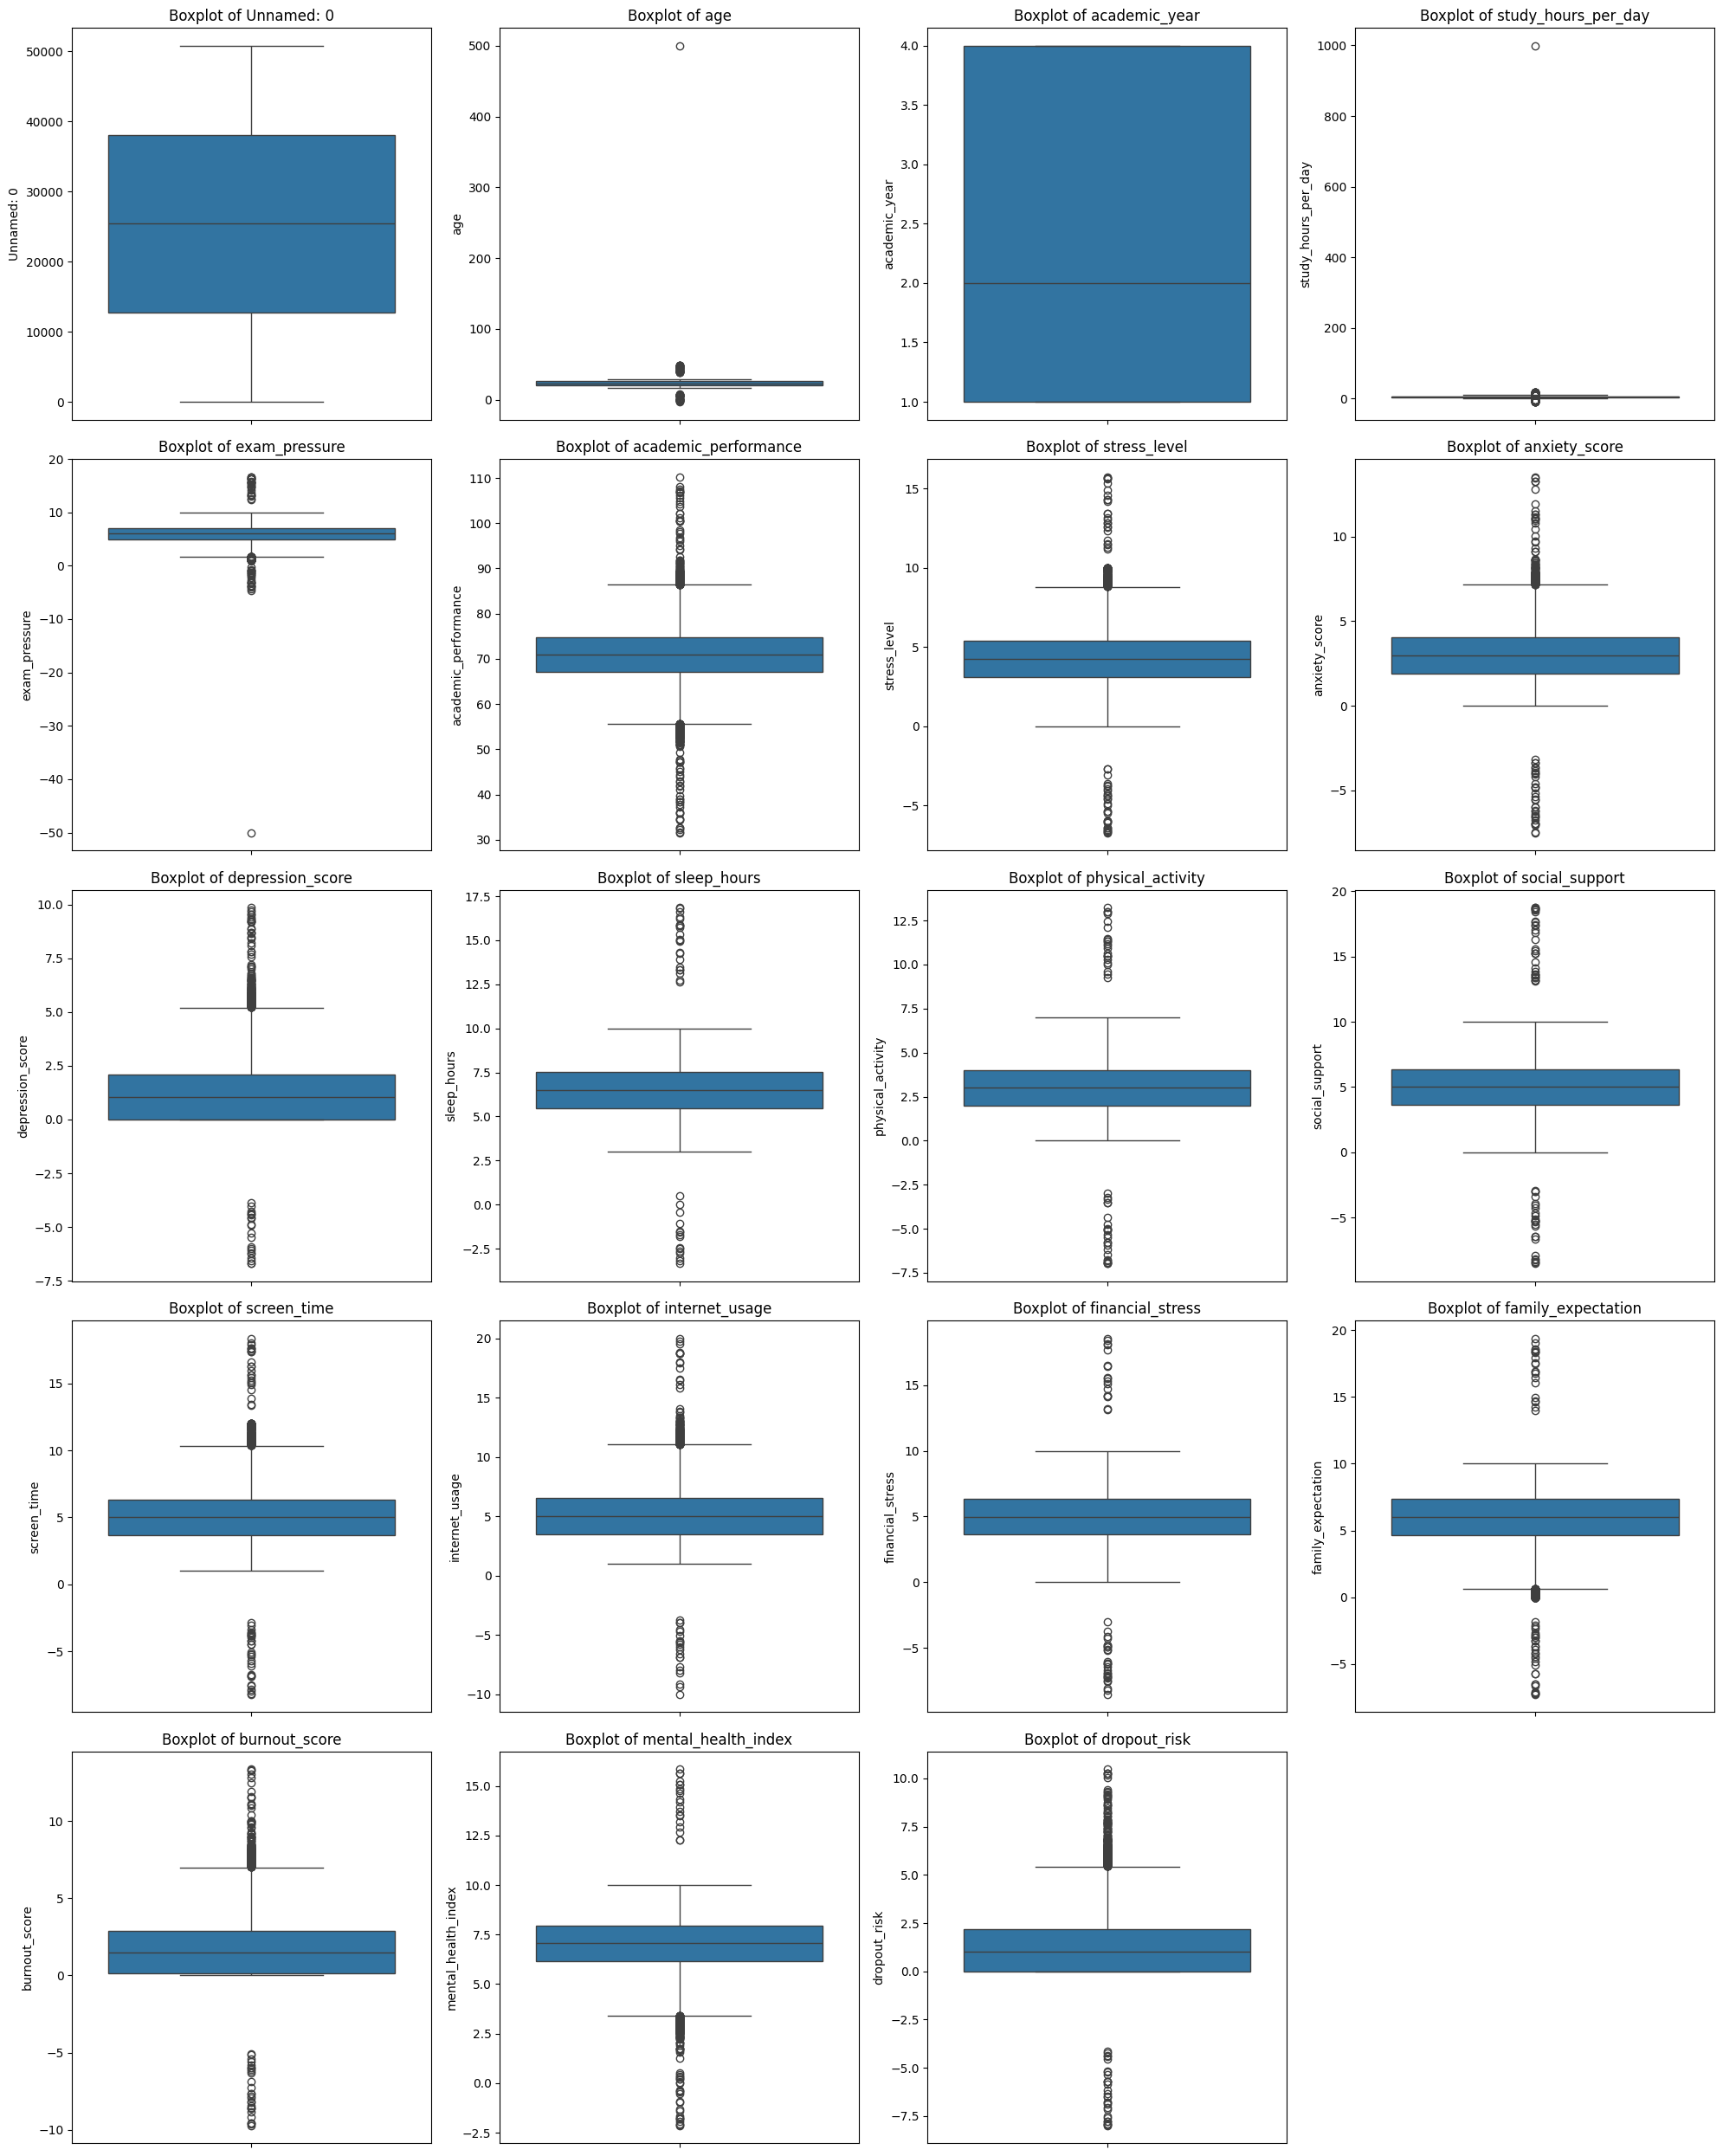

In [42]:
import math

# Calculate required rows based on a fixed width of 4 columns
cols = 4
rows = math.ceil(len(num) / cols)

plt.figure(figsize=(20, 5 * rows))

for i, k in enumerate(num):
    plt.subplot(rows, cols, i+1)
    sns.boxplot(y=k, data=df)
    plt.title(f"Boxplot of {k}")

plt.tight_layout()
plt.show()